## Setups and Imports

In [1]:
!pip install -q datasets

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from collections import Counter
import random

# Standard tokenizer
import re
def simple_tokenizer(text):
    return re.findall(r'\w+', text.lower())

# Set SEED 36
SEED = 36
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


## Loading and Preprocessing

In [3]:
# Load the dataset
print("Loading AG News...")
dataset = load_dataset("sh0416/ag_news")
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

def clean_text(df):
    # Combine title and description just like in A1
    df["x_text"] = df["title"].astype(str) + " " + df["description"].astype(str)
    # Basic cleaning: lowercase and remove backslashes
    df["x_text"] = df["x_text"].str.replace("\\", " ", regex=False).str.lower()
    return df

train_df = clean_text(train_df)
test_df = clean_text(test_df)

# Split train into train (90%) and validation (10%) using SEED 36
train, val = train_test_split(train_df, test_size=0.1, random_state=SEED)

print(f"Train size: {len(train)} | Val size: {len(val)} | Test size: {len(test_df)}")

Loading AG News...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train size: 108000 | Val size: 12000 | Test size: 7600


In [4]:
# creates a seed reset function to be sure we have the same randomizer always
def set_seed(seed=36):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

## Metrics

In [5]:
#setting up accuracy function
def accuracy(y_true, y_pred):
    #set y_true and y_pred as numpy arrays so we can use (i, len(y_pred)) as positional arguments
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    #initialize correct prediction count as 0
    same = 0
    for i in range(len(y_pred)):
        if y_true[i] == y_pred[i]:
            #if prediction was right, increse the count
            same += 1
    #return the accuracy
    return same / len(y_pred)

#setting a function that returns True Positives, True Negatives, False Positives and False Negatives, per label
def metrics(label, y_true, y_pred):
    tp = 0
    fp = 0
    fn = 0
    tn = 0
    for yt, yp in zip(y_true, y_pred):
        if yt == label and yp == label:
            tp += 1
        elif yt != label and yp == label:
            fp += 1
        elif yt == label and yp != label:
            fn += 1
        else:
            tn += 1
    return tp, fp, fn, tn

#calculates the f1-score given a label
def f1(label, y_true, y_pred):
    tp, fp, fn, tn = metrics(label, y_true, y_pred)
    precision = tp / (tp + fp) if tp + fp != 0 else 0
    recall = tp / (tp + fn) if tp + fn != 0 else 0
    return 2 * (precision * recall) / (precision + recall)


#calculates the macro f1 (average f1)
def macro_f1(y_true, y_pred):
    labels = sorted(set(y_true) | set(y_pred))
    sum = 0
    for label in labels:
        sum += f1(label, y_true, y_pred)
    return sum / 4

# uses sklearn's confusion matrix function
def conf_matrix(y_true, y_pred, class_names=["World", "Sports", "Business", "Sci/Tech"], normalize=False, save_path=None):
    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(
        cmap="Blues",
        values_format=".2f" if normalize else "d",
        ax=ax,
        colorbar=True
    )

    #ax.set_title("Normalized Confusion Matrix (Test Set)" if normalize else "Confusion Matrix (Test Set)")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


## Vocabulary and Tokenization

In [6]:
# Builds the Vocab Manually
all_tokens = Counter()
for text in train["x_text"]:
    all_tokens.update(simple_tokenizer(text))

# Keep words that appear at least 2 times
min_freq = 2
vocab = {"<pad>": 0, "<unk>": 1}
for word, freq in all_tokens.items():
    if freq >= min_freq:
        vocab[word] = len(vocab)

print(f"Vocab size: {len(vocab)}")

Vocab size: 42398


In [7]:
def numericalize(text, vocab, max_len):
    #tokenizes the text
    tokens = simple_tokenizer(text)
    # gets the corresponding indexes (<unk> if not seen)
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]
    #pads the sentence or truncates it
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

## Dataset Class

In [8]:
class AGNewsDataset(Dataset):
    def __init__(self, df, vocab, tokenizer, max_len):
        self.labels = df["label"].values - 1
        self.texts = df["x_text"].values
        self.vocab = vocab
        self.tokenizer = tokenizer
        self.max_len = max_len

        self.encoded_texts = [
            numericalize(text, self.vocab, self.max_len)
            for text in self.texts
        ]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.encoded_texts[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

# Hyperparameters
MAX_LEN = 64
BATCH_SIZE = 64

train_ds = AGNewsDataset(train, vocab, simple_tokenizer, MAX_LEN)
val_ds = AGNewsDataset(val, vocab, simple_tokenizer, MAX_LEN)
test_ds = AGNewsDataset(test_df, vocab, simple_tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

## Train functions

In [9]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy(all_labels, all_preds)
    macro_f1_score = macro_f1(all_labels, all_preds)

    return avg_loss, acc, macro_f1_score

In [10]:
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    acc = accuracy(all_labels, all_preds)
    macro_f1_score = macro_f1(all_labels, all_preds)

    return avg_loss, acc, macro_f1_score, all_labels, all_preds

## LSTM Model

In [11]:
# Model architecture
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, pad, embed_dim, hidden_dim, output_dim, dropout_rate=0):
        super().__init__()
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad)

        # Bidirectional LSTM
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Fully connected layer (hidden_dim * 2 because of bidirectionality)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, text):
        # text: [batch size, seq len]
        embedded = self.dropout(self.embedding(text))

        # lstm returns: output and (hidden, cell)
        _, (hidden, _) = self.lstm(embedded)

        # Concatenate the final forward and backward hidden states
        # hidden[-2,:,:] is last forward, hidden[-1,:,:] is last backward
        hidden_final = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)

        return self.fc(self.dropout(hidden_final))


In [13]:
# Initialize model
set_seed(SEED)
EMBED_DIM = 100
HIDDEN_DIM = 64
pad = vocab["<pad>"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm = LSTMClassifier(len(vocab), pad, EMBED_DIM, HIDDEN_DIM, 4).to(device)
print(model_lstm)

LSTMClassifier(
  (embedding): Embedding(42398, 100, padding_idx=0)
  (lstm): LSTM(100, 64, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=128, out_features=4, bias=True)
  (dropout): Dropout(p=0, inplace=False)
)


In [14]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)

In [16]:
#maximum of 50 epochs, early stopping in case of 5 epochs with no improvement
PATIENCE = 5
NUM_EPOCHS = 50

history_lstm = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1_lstm = -1
best_model_state_lstm = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_f1 = train_epoch(
        model_lstm, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_lstm, val_loader, criterion, device
    )

    history_lstm["train_loss"].append(train_loss)
    history_lstm["train_acc"].append(train_acc)
    history_lstm["train_f1"].append(train_f1)
    history_lstm["val_loss"].append(val_loss)
    history_lstm["val_acc"].append(val_acc)
    history_lstm["val_f1"].append(val_f1)
  #checks if there was improvement
    if val_f1 > best_val_f1_lstm:
        best_val_f1_lstm = val_f1
        best_model_state_lstm = model_lstm.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"Patience: {epochs_without_improvement}/{PATIENCE}")
    print("-" * 60)

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

model_lstm.load_state_dict(best_model_state_lstm)
print(f"Best validation Macro-F1: {best_val_f1_lstm:.4f}")

Epoch 1/50
Train Loss: 0.5162 | Train Acc: 0.8083 | Train F1: 0.8079
Val   Loss: 0.3320 | Val   Acc: 0.8882 | Val   F1: 0.8884
Patience: 0/5
------------------------------------------------------------
Epoch 2/50
Train Loss: 0.2545 | Train Acc: 0.9155 | Train F1: 0.9154
Val   Loss: 0.2935 | Val   Acc: 0.9022 | Val   F1: 0.9023
Patience: 0/5
------------------------------------------------------------
Epoch 3/50
Train Loss: 0.1878 | Train Acc: 0.9378 | Train F1: 0.9377
Val   Loss: 0.2777 | Val   Acc: 0.9093 | Val   F1: 0.9096
Patience: 0/5
------------------------------------------------------------
Epoch 4/50
Train Loss: 0.1435 | Train Acc: 0.9528 | Train F1: 0.9527
Val   Loss: 0.2801 | Val   Acc: 0.9083 | Val   F1: 0.9089
Patience: 1/5
------------------------------------------------------------
Epoch 5/50
Train Loss: 0.1085 | Train Acc: 0.9645 | Train F1: 0.9645
Val   Loss: 0.3040 | Val   Acc: 0.9029 | Val   F1: 0.9034
Patience: 2/5
---------------------------------------------------

Validation Loss: 0.3966
Validation Acc: 0.9017
Validation Macro-F1: 0.9022


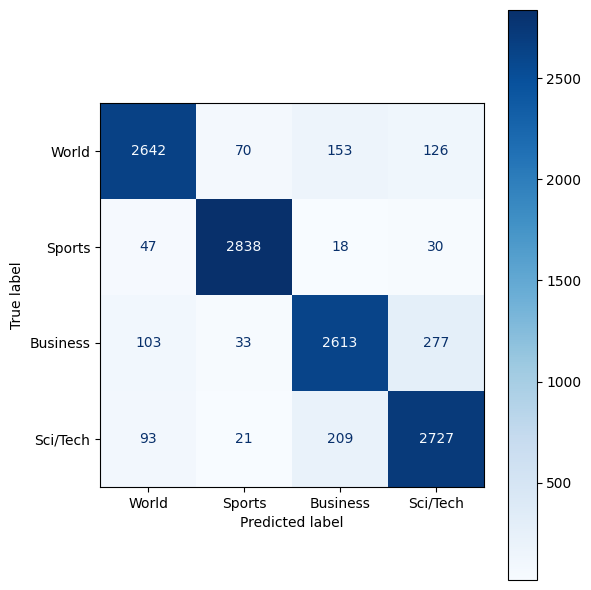

In [17]:
# after training and after loading the best checkpoint
model_lstm.load_state_dict(best_model_state_lstm)

val_loss, val_acc, val_f1, y_true_val, y_pred_val = evaluate(
    model_lstm, val_loader, criterion, device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Acc: {val_acc:.4f}")
print(f"Validation Macro-F1: {val_f1:.4f}")

conf_matrix(y_true_val, y_pred_val, normalize=False)

## CNN Model


In [18]:
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, pad_idx, embed_dim, num_filters, kernel_sizes, output_dim, dropout_rate=0):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        embedded = embedded.permute(0, 2, 1)

        conv_results = [torch.relu(conv(embedded)) for conv in self.convs]
        pooled = [torch.max(conv_out, dim=2).values for conv_out in conv_results]

        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

In [19]:
set_seed(SEED)

In [27]:
#hyperparameters
EMBED_DIM = 100
NUM_FILTERS = 100
KERNEL_SIZES = [3, 4, 5]
pad_idx = vocab["<pad>"]
set_seed(SEED)
model_cnn = CNNClassifier(
    vocab_size=len(vocab),
    pad_idx=pad_idx,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    output_dim=4,
    dropout_rate=0.0
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)

In [28]:
PATIENCE = 5
NUM_EPOCHS = 50

history_cnn = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1_cnn = -1
best_model_state_cnn = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_f1 = train_epoch(
        model_cnn, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_cnn, val_loader, criterion, device
    )

    history_cnn["train_loss"].append(train_loss)
    history_cnn["train_acc"].append(train_acc)
    history_cnn["train_f1"].append(train_f1)
    history_cnn["val_loss"].append(val_loss)
    history_cnn["val_acc"].append(val_acc)
    history_cnn["val_f1"].append(val_f1)

    if val_f1 > best_val_f1_cnn:
        best_val_f1_cnn = val_f1
        best_model_state_cnn = model_cnn.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"Patience: {epochs_without_improvement}/{PATIENCE}")
    print("-" * 60)

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

model_cnn.load_state_dict(best_model_state_cnn)
print(f"Best validation Macro-F1: {best_val_f1_cnn:.4f}")

Epoch 1/50
Train Loss: 0.4682 | Train Acc: 0.8344 | Train F1: 0.8340
Val   Loss: 0.3462 | Val   Acc: 0.8763 | Val   F1: 0.8772
Patience: 0/5
------------------------------------------------------------
Epoch 2/50
Train Loss: 0.2219 | Train Acc: 0.9269 | Train F1: 0.9268
Val   Loss: 0.3161 | Val   Acc: 0.8947 | Val   F1: 0.8949
Patience: 0/5
------------------------------------------------------------
Epoch 3/50
Train Loss: 0.1238 | Train Acc: 0.9601 | Train F1: 0.9600
Val   Loss: 0.3611 | Val   Acc: 0.8861 | Val   F1: 0.8874
Patience: 1/5
------------------------------------------------------------
Epoch 4/50
Train Loss: 0.0674 | Train Acc: 0.9791 | Train F1: 0.9791
Val   Loss: 0.4234 | Val   Acc: 0.8918 | Val   F1: 0.8922
Patience: 2/5
------------------------------------------------------------
Epoch 5/50
Train Loss: 0.0464 | Train Acc: 0.9866 | Train F1: 0.9866
Val   Loss: 0.4434 | Val   Acc: 0.8948 | Val   F1: 0.8952
Patience: 0/5
---------------------------------------------------

Validation Loss: 0.6432
Validation Acc: 0.8945
Validation Macro-F1: 0.8947


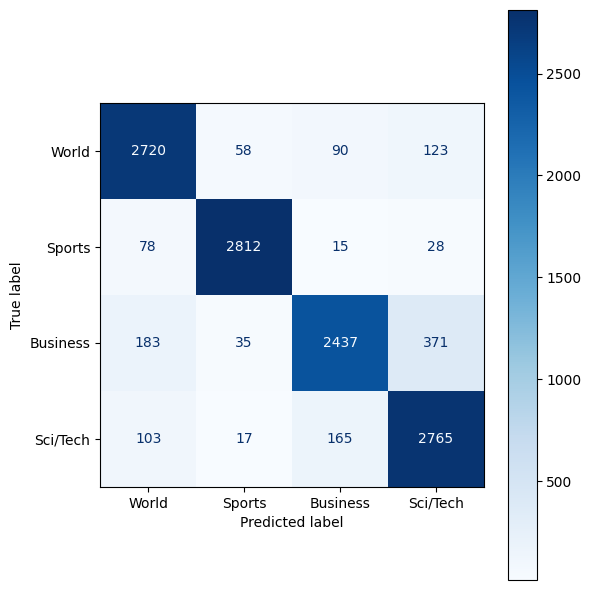

In [29]:
# after training and after loading the best checkpoint
model_cnn.load_state_dict(best_model_state_cnn)

val_loss, val_acc, val_f1, y_true_val, y_pred_val = evaluate(
    model_cnn, val_loader, criterion, device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Acc: {val_acc:.4f}")
print(f"Validation Macro-F1: {val_f1:.4f}")

conf_matrix(y_true_val, y_pred_val, normalize=False)

## Learning curves

In [30]:
def plot_learning_curves(history, model_name="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], marker="o")
    plt.plot(epochs, history["val_loss"], marker="o")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_f1"], marker="o")
    plt.plot(epochs, history["val_f1"], marker="o")
    plt.title(f"{model_name} Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend(["Train F1", "Val F1"])

    plt.tight_layout()
    plt.show()

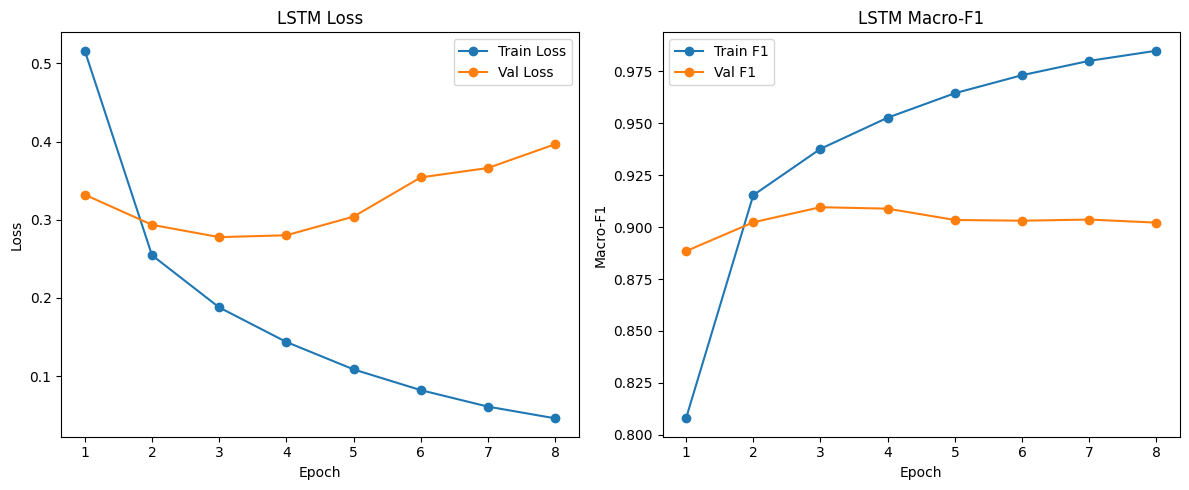

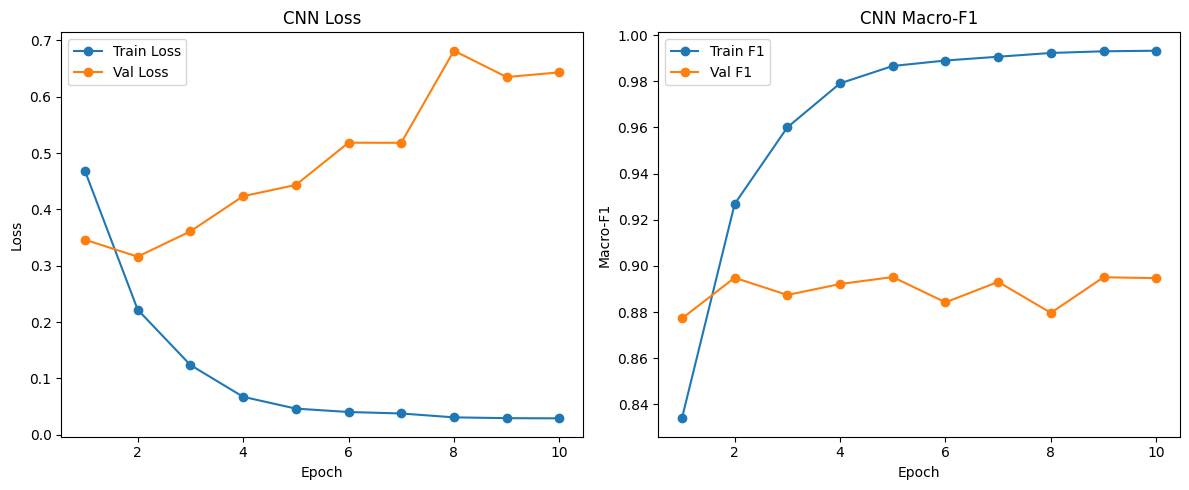

In [31]:
plot_learning_curves(history_lstm, "LSTM")
plot_learning_curves(history_cnn, "CNN")

## Ablation

### CNN

In [32]:
#hyperparameters
set_seed(SEED)
EMBED_DIM = 100
NUM_FILTERS = 100
KERNEL_SIZES = [3, 4, 5]
pad_idx = vocab["<pad>"]
set_seed(SEED)
model_cnn_abl = CNNClassifier(
    vocab_size=len(vocab),
    pad_idx=pad_idx,
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    kernel_sizes=KERNEL_SIZES,
    output_dim=4,
    dropout_rate=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn_abl.parameters(), lr=1e-3)

In [33]:
PATIENCE = 5
NUM_EPOCHS = 50

history_cnn_abl = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1_cnn_abl = -1
best_model_state_cnn_abl = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_f1 = train_epoch(
        model_cnn_abl, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_cnn_abl, val_loader, criterion, device
    )

    history_cnn_abl["train_loss"].append(train_loss)
    history_cnn_abl["train_acc"].append(train_acc)
    history_cnn_abl["train_f1"].append(train_f1)
    history_cnn_abl["val_loss"].append(val_loss)
    history_cnn_abl["val_acc"].append(val_acc)
    history_cnn_abl["val_f1"].append(val_f1)

    if val_f1 > best_val_f1_cnn_abl:
        best_val_f1_cnn_abl = val_f1
        best_model_state = model_cnn_abl.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"Patience: {epochs_without_improvement}/{PATIENCE}")
    print("-" * 60)

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

model_cnn_abl.load_state_dict(best_model_state)
print(f"Best validation Macro-F1: {best_val_f1_cnn_abl:.4f}")

Epoch 1/50
Train Loss: 0.5738 | Train Acc: 0.7824 | Train F1: 0.7819
Val   Loss: 0.3445 | Val   Acc: 0.8867 | Val   F1: 0.8873
Patience: 0/5
------------------------------------------------------------
Epoch 2/50
Train Loss: 0.3149 | Train Acc: 0.8925 | Train F1: 0.8923
Val   Loss: 0.3098 | Val   Acc: 0.9017 | Val   F1: 0.9019
Patience: 0/5
------------------------------------------------------------
Epoch 3/50
Train Loss: 0.2380 | Train Acc: 0.9196 | Train F1: 0.9194
Val   Loss: 0.2985 | Val   Acc: 0.9023 | Val   F1: 0.9031
Patience: 0/5
------------------------------------------------------------
Epoch 4/50
Train Loss: 0.1914 | Train Acc: 0.9351 | Train F1: 0.9350
Val   Loss: 0.3045 | Val   Acc: 0.9020 | Val   F1: 0.9023
Patience: 1/5
------------------------------------------------------------
Epoch 5/50
Train Loss: 0.1530 | Train Acc: 0.9476 | Train F1: 0.9476
Val   Loss: 0.3174 | Val   Acc: 0.9049 | Val   F1: 0.9053
Patience: 0/5
---------------------------------------------------

Validation Loss: 0.5149
Validation Acc: 0.9028
Validation Macro-F1: 0.9033


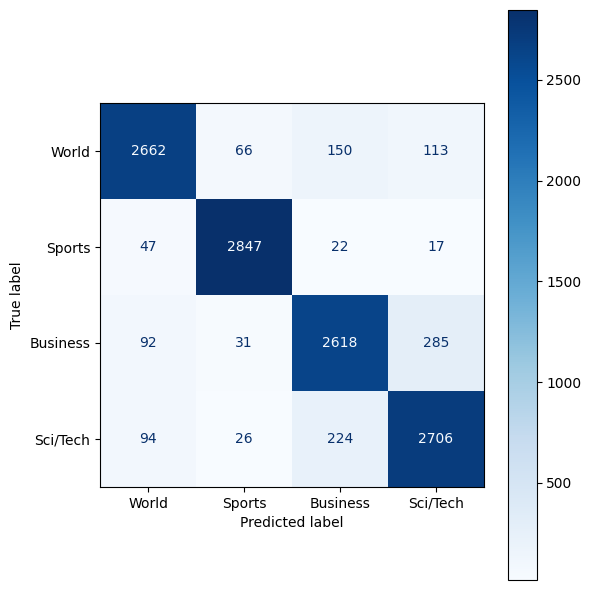

In [40]:
val_loss, val_acc, val_f1, y_true_val, y_pred_val = evaluate(
    model_cnn_abl, val_loader, criterion, device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Acc: {val_acc:.4f}")
print(f"Validation Macro-F1: {val_f1:.4f}")

conf_matrix(y_true_val, y_pred_val, normalize=False)

### LSTM

In [34]:
set_seed(SEED)
EMBED_DIM = 100
HIDDEN_DIM = 64
pad = vocab["<pad>"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_lstm_abl = LSTMClassifier(len(vocab), pad, EMBED_DIM, HIDDEN_DIM, 4, 0.3).to(device)
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_lstm_abl.parameters(), lr=1e-3)

In [35]:
PATIENCE = 5
NUM_EPOCHS = 50

history_lstm_abl = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1_lstm_abl = -1
best_model_state = None
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_f1 = train_epoch(
        model_lstm_abl, train_loader, optimizer, criterion, device
    )

    val_loss, val_acc, val_f1, _, _ = evaluate(
        model_lstm_abl, val_loader, criterion, device
    )

    history_lstm_abl["train_loss"].append(train_loss)
    history_lstm_abl["train_acc"].append(train_acc)
    history_lstm_abl["train_f1"].append(train_f1)
    history_lstm_abl["val_loss"].append(val_loss)
    history_lstm_abl["val_acc"].append(val_acc)
    history_lstm_abl["val_f1"].append(val_f1)

    if val_f1 > best_val_f1_lstm_abl:
        best_val_f1_lstm_abl = val_f1
        best_model_state = model_lstm_abl.state_dict()
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val   F1: {val_f1:.4f}")
    print(f"Patience: {epochs_without_improvement}/{PATIENCE}")
    print("-" * 60)

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

model_lstm_abl.load_state_dict(best_model_state)
print(f"Best validation Macro-F1: {best_val_f1_lstm_abl:.4f}")

Epoch 1/50
Train Loss: 0.6659 | Train Acc: 0.7406 | Train F1: 0.7400
Val   Loss: 0.3780 | Val   Acc: 0.8742 | Val   F1: 0.8743
Patience: 0/5
------------------------------------------------------------
Epoch 2/50
Train Loss: 0.3555 | Train Acc: 0.8790 | Train F1: 0.8787
Val   Loss: 0.3449 | Val   Acc: 0.8885 | Val   F1: 0.8889
Patience: 0/5
------------------------------------------------------------
Epoch 3/50
Train Loss: 0.2894 | Train Acc: 0.9026 | Train F1: 0.9024
Val   Loss: 0.3033 | Val   Acc: 0.9062 | Val   F1: 0.9067
Patience: 0/5
------------------------------------------------------------
Epoch 4/50
Train Loss: 0.2526 | Train Acc: 0.9153 | Train F1: 0.9151
Val   Loss: 0.3120 | Val   Acc: 0.9067 | Val   F1: 0.9072
Patience: 0/5
------------------------------------------------------------
Epoch 5/50
Train Loss: 0.2251 | Train Acc: 0.9248 | Train F1: 0.9247
Val   Loss: 0.2926 | Val   Acc: 0.9122 | Val   F1: 0.9125
Patience: 0/5
---------------------------------------------------

Validation Loss: 0.3481
Validation Acc: 0.9126
Validation Macro-F1: 0.9130


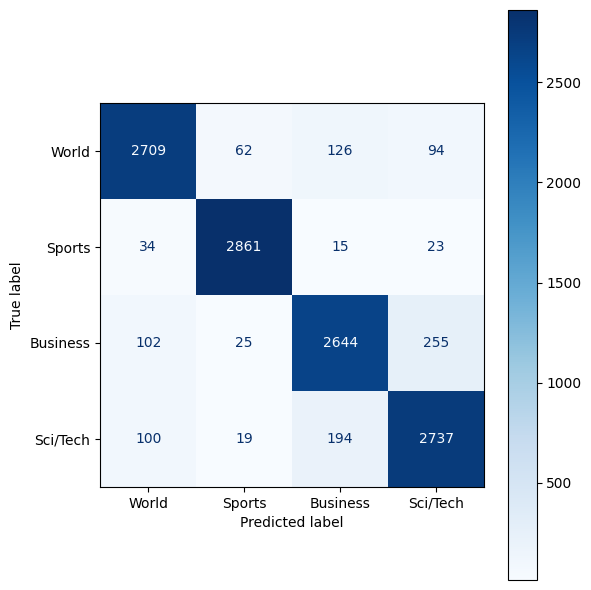

In [41]:
val_loss, val_acc, val_f1, y_true_val, y_pred_val = evaluate(
    model_lstm_abl, val_loader, criterion, device
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Acc: {val_acc:.4f}")
print(f"Validation Macro-F1: {val_f1:.4f}")

conf_matrix(y_true_val, y_pred_val, normalize=False)

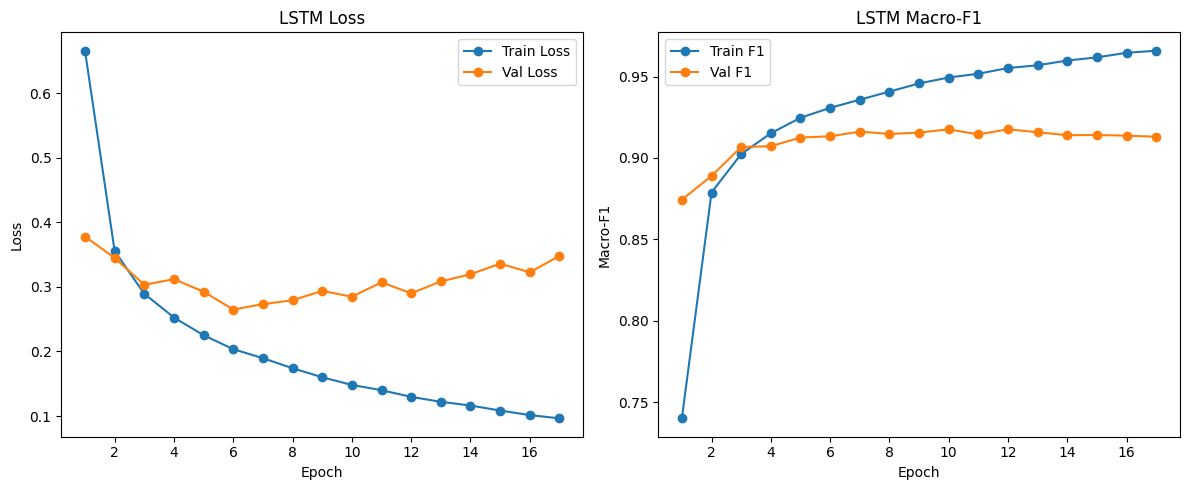

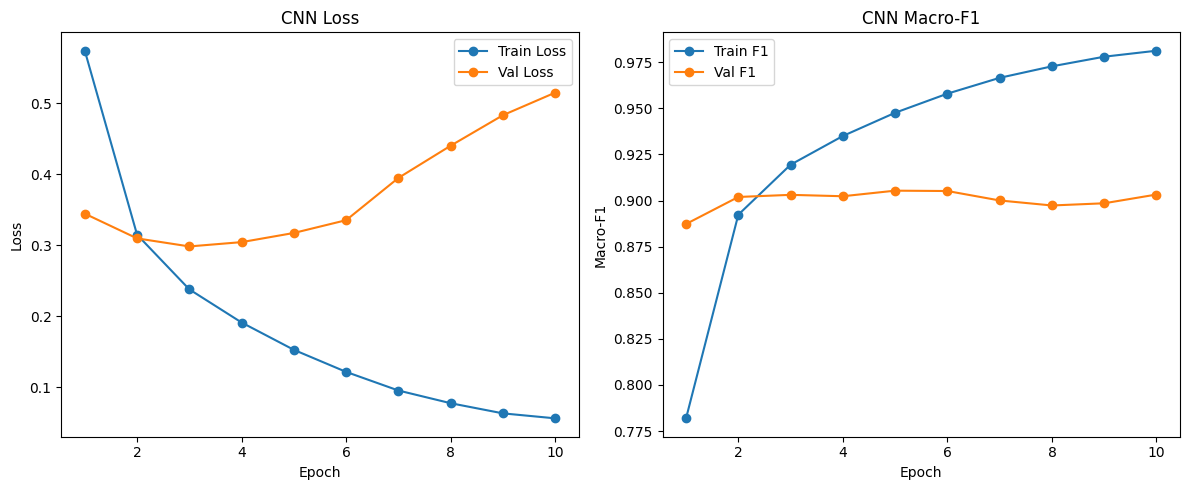

In [36]:
plot_learning_curves(history_lstm_abl, "LSTM")
plot_learning_curves(history_cnn_abl, "CNN")

## Testing

In [44]:
# the best model was the lstm with a dropout rate of 0.3

test_loss, test_acc, test_f1, y_true_test, y_pred_test = evaluate(
    model_lstm_abl, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc: {test_acc:.4f}")
print(f"Test Macro-F1: {test_f1:.4f}")

Test Loss: 0.3224
Test Acc: 0.9182
Test Macro-F1: 0.9180


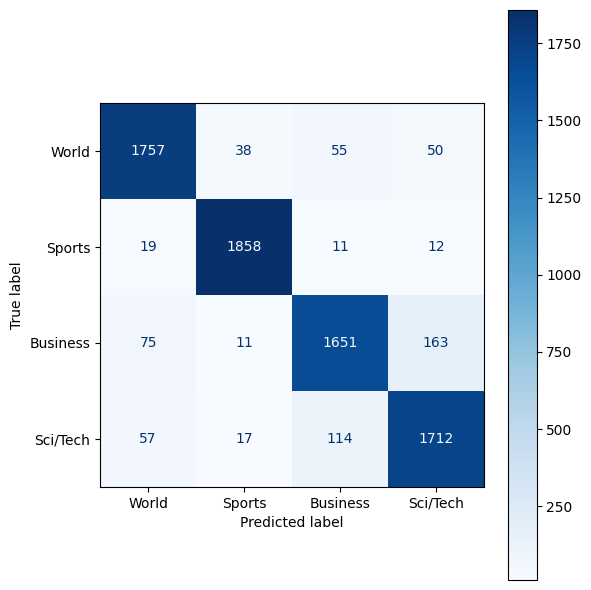

In [43]:
conf_matrix(y_true_test, y_pred_test, normalize=False)